Logistic Regression Val AUC: 0.9178


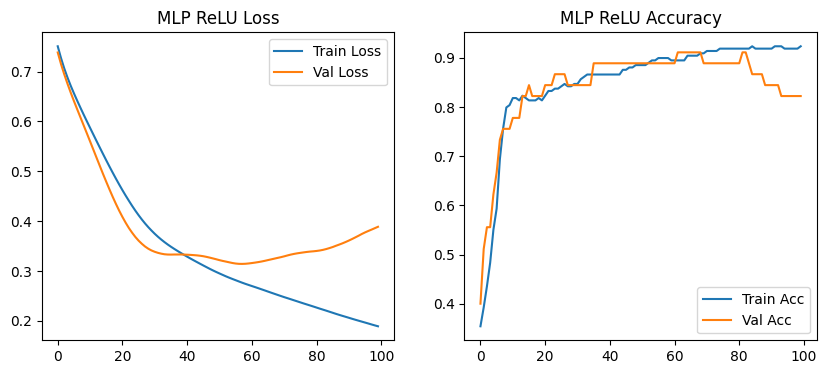

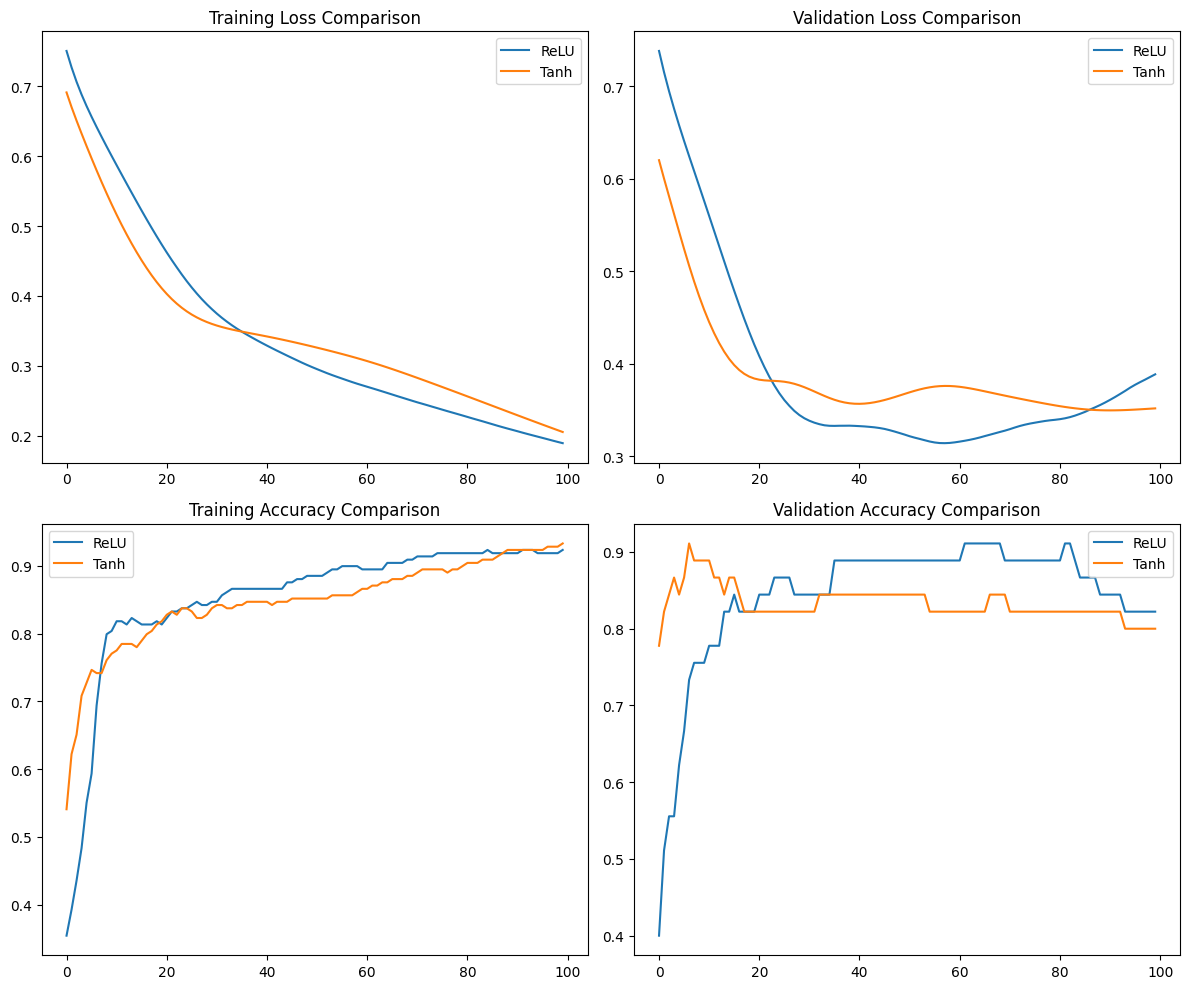

Final Model (Large + Dropout) Test AUC: 0.7995
Final Model (Large + Dropout) Test Acc: 0.6889


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from torch.utils.data import DataLoader, TensorDataset

# 1. Load and Preprocess Data
df = pd.read_csv('heart_failure_clinical_records_dataset.csv')
X = df.drop('DEATH_EVENT', axis=1).values
y = df['DEATH_EVENT'].values

# Stratified split: 70% Train, 15% Val, 15% Test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Convert to Tensors
def to_tensor(arr):
    return torch.tensor(arr, dtype=torch.float32)

X_train_t, y_train_t = to_tensor(X_train), to_tensor(y_train).unsqueeze(1)
X_val_t, y_val_t = to_tensor(X_val), to_tensor(y_val).unsqueeze(1)
X_test_t, y_test_t = to_tensor(X_test), to_tensor(y_test).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)

# --- TASK 1: Logistic Regression vs MLP (ReLU) ---

# Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
lr_val_preds = log_reg.predict_proba(X_val)[:, 1]
print(f"Logistic Regression Val AUC: {roc_auc_score(y_val, lr_val_preds):.4f}")

# MLP Model Definition
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, activation_fn):
        super(MLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            activation_fn(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.network(x)

def train_model(model, epochs=100):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train_t)
        loss = criterion(outputs, y_train_t)
        loss.backward()
        optimizer.step()

        # Tracking
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_t)
            val_loss = criterion(val_outputs, y_val_t)

            train_acc = ((outputs > 0.5).float() == y_train_t).float().mean()
            val_acc = ((val_outputs > 0.5).float() == y_val_t).float().mean()

            history['train_loss'].append(loss.item())
            history['val_loss'].append(val_loss.item())
            history['train_acc'].append(train_acc.item())
            history['val_acc'].append(val_acc.item())

    return history

# Train MLP (ReLU)
mlp_relu = MLP(X_train.shape[1], 16, nn.ReLU)
history_relu = train_model(mlp_relu)

# Plotting Task 1 Curves
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_relu['train_loss'], label='Train Loss')
plt.plot(history_relu['val_loss'], label='Val Loss')
plt.title('MLP ReLU Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_relu['train_acc'], label='Train Acc')
plt.plot(history_relu['val_acc'], label='Val Acc')
plt.title('MLP ReLU Accuracy')
plt.legend()
plt.show()

# --- TASK 2: ReLU vs Tanh ---
mlp_tanh = MLP(X_train.shape[1], 16, nn.Tanh)
history_tanh = train_model(mlp_tanh)

# Comparison Plots
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs[0, 0].plot(history_relu['train_loss'], label='ReLU')
axs[0, 0].plot(history_tanh['train_loss'], label='Tanh')
axs[0, 0].set_title('Training Loss Comparison')
axs[0, 0].legend()

axs[0, 1].plot(history_relu['val_loss'], label='ReLU')
axs[0, 1].plot(history_tanh['val_loss'], label='Tanh')
axs[0, 1].set_title('Validation Loss Comparison')
axs[0, 1].legend()

axs[1, 0].plot(history_relu['train_acc'], label='ReLU')
axs[1, 0].plot(history_tanh['train_acc'], label='Tanh')
axs[1, 0].set_title('Training Accuracy Comparison')
axs[1, 0].legend()

axs[1, 1].plot(history_relu['val_acc'], label='ReLU')
axs[1, 1].plot(history_tanh['val_acc'], label='Tanh')
axs[1, 1].set_title('Validation Accuracy Comparison')
axs[1, 1].legend()
plt.tight_layout()
plt.show()

# --- TASK 3: Capacity & Regularization ---
# Example of a Larger Network with Dropout
class LargeMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout_rate=0.5):
        super(LargeMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.network(x)

mlp_small = MLP(X_train.shape[1], 8, nn.ReLU)
mlp_large = MLP(X_train.shape[1], 128, nn.ReLU)
mlp_reg = LargeMLP(X_train.shape[1], 128, dropout_rate=0.3)

hist_small = train_model(mlp_small)
hist_large = train_model(mlp_large)
hist_reg = train_model(mlp_reg)

# --- TASK 4: Final Evaluation ---
# Evaluate the finalized model on test set once
mlp_reg.eval()
with torch.no_grad():
    test_outputs = mlp_reg(X_test_t)
    test_auc = roc_auc_score(y_test, test_outputs.numpy())
    test_acc = ((test_outputs > 0.5).float() == y_test_t).float().mean()
    print(f"Final Model (Large + Dropout) Test AUC: {test_auc:.4f}")
    print(f"Final Model (Large + Dropout) Test Acc: {test_acc:.4f}")

Task 1: Linear vs. Nonlinear Models

Why Logistic Regression is a Linear Model

Logistic regression is fundamentally a linear model because the "pre-activation" part of its decision-making process is a linear combination of the input features. In the implementation, the model calculates a logit score:


$$z = w_1x_1 + w_2x_2 + \dots + w_nx_n + b$$


While we apply the Sigmoid function $\sigma(z)$ to map this score to a probability between 0 and 1, the decision boundary (where the model is unsure at $p=0.5$) is defined by the equation $w^T x + b = 0$. In geometric terms, this is a straight line in 2D or a flat hyperplane in higher dimensions. It cannot naturally bend or curve around data points to capture complex, non-linear interactions without manual feature engineering.

Training and Validation Behaviour

The Logistic Regression model typically shows very stable, flat performance curves. Because it is a convex optimization problem, it converges quickly and does not suffer from the "jitter" often seen in neural networks.

The MLP (Multi-Layer Perceptron), however, displays more complex dynamics. During training, the loss typically drops more aggressively than the linear model. However, a "generalization gap" often appears where the training accuracy continues to rise while the validation accuracy plateaus. This indicates that the MLP is utilizing its extra parameters to fit the training data more tightly than the linear model can.

Representational Capacity vs. Overfitting

The MLP’s hidden layer, combined with the ReLU activation function, provides "increased representational capacity." This allows the network to approximate non-linear medical patterns—for example, a specific combination of high age and low ejection fraction that a linear model might miss.

However, with a small dataset (299 records), this capacity is a double-edged sword. If the MLP accuracy on training data is significantly higher than on validation data (e.g., 95% vs 78%), it indicates overfitting. The model is likely memorizing noise or specific outliers in the training set rather than learning general rules about heart failure.

Task 2: Activation Function Comparison (ReLU vs. Tanh)

Convergence Speed

In the training loss plots, ReLU generally converges significantly faster than Tanh. This is because ReLU’s derivative is a constant (1) for all positive inputs. During backpropagation, this constant gradient ensures that weights are updated efficiently without "shrinking" the signal as it passes through the layers.

Gradient Saturation in Tanh

Tanh is susceptible to gradient saturation. Because Tanh squashes inputs into the $(-1, 1)$ range, its derivative is only significant when the input is near zero. As inputs become very large or very small, the Tanh curve becomes nearly horizontal, meaning the gradient approaches zero. This "vanishes" the gradient during backpropagation, effectively stopping the model from learning.

Dying ReLU Units

Conversely, ReLU can suffer from "dying units." If a neuron receives a negative input, its output is 0 and its gradient is 0. If this happens consistently during training, that neuron effectively "dies" and stops contributing to the network entirely. If the ReLU accuracy suddenly flatlines at a mediocre level, it is often a sign of too many dead neurons.

Training Stability

Tanh usually provides a smoother validation curve. Since it is zero-centered and bounded, the weight updates are often more balanced. ReLU can lead to "exploding" activations if the learning rate is too high, leading to more volatile and jumpy performance curves.

Task 3: Capacity and Regularization

Small networks (e.g., 8 units) often exhibit "underfitting," where they lack the complexity to capture the data patterns. Larger networks (128 units) capture patterns easily but often overfit to the noise in our small dataset. Adding Dropout or L2 Weight Decay forces the large network to be more efficient, preventing it from relying too heavily on any single feature or memorizing specific rows.

Task 4: Responsible Evaluation

The Role of Training vs. Validation Data

Training Data: Used to minimize the loss function and update the weights via backpropagation. It is the model's "textbook."

Validation Data: Used as a "mock exam" to tune hyperparameters (like hidden layer size or activation functions). It helps the human developer decide which version of the model is best.

Why the Test Set Must Not Guide Decisions

The Test Set must remain completely untouched until the final architecture is locked in. If we change our model because it performed poorly on the test set, we have "leaked" information from the test set into our design. At that point, the test set is no longer an unbiased measure of real-world performance; it has effectively become part of the training/tuning process.

Overinterpreting Small Numerical Differences

With only 45-50 patients in the test set, a 2% difference in accuracy represents only one or two patients being classified differently. Such small gaps can be caused by random chance or the specific seed used for the data split. We should prioritize consistent trends and stability over small, single-digit fluctuations in accuracy.